In [ ]:
# install libraries
!pip install requests pandas nltk textblob vaderSentiment beautifulsoup4 matplotlib seaborn wordcloud plotly

## NEWS API
[text](https://newsapi.org/register)

Account detail
bala.sbm.kk@gmail.com
Demo@1234

api key
f18eab0734014db589aa291c1f6ee071

In [1]:
# Download NLTK data

import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('averaged_perceptron_tagger_eng')

print("✅ All dependencies installed and ready!")

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\subramm6\AppData\Roaming\nltk_data...


✅ All dependencies installed and ready!


[nltk_data]   Unzipping taggers\averaged_perceptron_tagger_eng.zip.


In [4]:
# ── Core libraries ──────────────────────────────────────────────
import requests
import json
import re
import time
from datetime import datetime

# ── Data handling ────────────────────────────────────────────────
import pandas as pd

# ── NLP ──────────────────────────────────────────────────────────

import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.probability import FreqDist
from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer


# ── Web Scraping ─────────────────────────────────────────────────
from bs4 import BeautifulSoup

# ── Visualization ─────────────────────────────────────────────────

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from wordcloud import WordCloud
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

print('imported successfully...')

imported successfully...


In [1]:
NEWS_API_KEY = "f18eab0734014db589aa291c1f6ee071"
CATEGORIES = ["technology", "business"]
SEARCH_QUERIES = ["economy", "artificial intelligence"]
PAGE_SIZE = 1
COUNTRY ="us"
BASE_URL = "https://newsapi.org/v2"

In [5]:
all_articles = []
def fetch_top_headlines(category:str, country:str, page_size:int=PAGE_SIZE) -> list:
   url = f"{BASE_URL}/top-headlines"
   print(url)
   request = {
       "apiKey" : NEWS_API_KEY,
       "category": category,
       "country": country,
       "pageSize" : page_size
   }
   print(request)
   response = requests.get(url, params=request, timeout=10)
   print(response)
   if(response.status_code != 200):
       print(f" API error {response.status_code}")
   articles = response.json().get('articles', [])
   print(articles)
   return articles


for cat in CATEGORIES:
   articles = fetch_top_headlines(category=cat, country=COUNTRY)
   for art in articles:
       art["query_category"] = cat
   all_articles.extend(articles)
print(all_articles)


https://newsapi.org/v2/top-headlines
{'apiKey': 'f18eab0734014db589aa291c1f6ee071', 'category': 'technology', 'country': 'us', 'pageSize': 1}
<Response [200]>
[{'source': {'id': None, 'name': 'My Nintendo News'}, 'author': 'Sickr', 'title': 'Persona 4 Revival due to be completed end of August and release early 2027 - My Nintendo News', 'description': 'Tose is the Japanese third party studio which is co-developing the long-awaited Persona 4 Revival from Atlus. In a recent finical report, which shows the company’s progress on five projects…', 'url': 'https://mynintendonews.com/2026/05/04/persona-4-revival-due-to-be-completed-end-of-august-and-release-early-2027/', 'urlToImage': 'https://i0.wp.com/mynintendonews.com/wp-content/uploads/2022/12/persona_4_golden_art.jpeg?fit=1280%2C720&ssl=1', 'publishedAt': '2026-05-04T13:36:51Z', 'content': 'Tose is the Japanese third party studio which is co-developing the long-awaited Persona 4 Revival from Atlus. In a recent finical report, which shows 

In [6]:
def fetch_by_keyword(query:str, page_size:int=PAGE_SIZE) -> list:
   url = f"{BASE_URL}/everything"
   print(url)
   request = {
       "apiKey" : NEWS_API_KEY,
       "q": query,
       "language": "en",
       "sortBy": "publishedAt",
       "pageSize": page_size
   }
   print(request)
   response = requests.get(url, params=request, timeout=10)
   print(response)
   if(response.status_code != 200):
       print(f" API error {response.status_code}")
   articles = response.json().get('articles', [])
   print(articles)
   return articles


for query in SEARCH_QUERIES:
   articles = fetch_by_keyword(query=query)
   for art in articles:
       art["query_category"] = f"kw:{query}"
   all_articles.extend(articles)


for art in all_articles:
   print(art)

https://newsapi.org/v2/everything
{'apiKey': 'f18eab0734014db589aa291c1f6ee071', 'q': 'economy', 'language': 'en', 'sortBy': 'publishedAt', 'pageSize': 1}
<Response [200]>
[{'source': {'id': None, 'name': 'Theflightdeal.com'}, 'author': 'The Flight Deal', 'title': 'Asiana Airlines: Seattle – Ho Chi Minh City, Vietnam. $740. Roundtrip, including all Taxes', 'description': 'A good sale to VietnamVietnam introduced a new e-Visa system - take advantage of it. Its the cheapest option.Matrix Airfare Search will price this at $752. Use those dates on Priceline should', 'url': 'https://www.theflightdeal.com/2026/05/04/asiana-airlines-seattle-ho-chi-minh-city-vietnam-740-roundtrip-including-all-taxes/', 'urlToImage': 'https://www.theflightdeal.com/wp-content/uploads/2014/08/ho_chi_minh_city_opera_house-640x390.jpg', 'publishedAt': '2026-05-04T17:03:38Z', 'content': 'A good sale to Vietnam\r\nVietnam introduced a new e-Visa system take advantage of it. Its the cheapest option.\r\nMatrix Airfare 

In [9]:
def articles_to_dataframe(articles:list) -> pd.DataFrame:
   rows = []
   for art in articles:
       rows.append({
           "title": art.get("title") or "",
           "description" : art.get("description") or "",
           "source" : art.get("source", {}).get("name") or "Unknown",
           "url": art.get("url") or "",
           "published_at" : art.get("publishedAt") or "",
           "category" : art.get("query_category"),
           "full_text" : " ".join(filter(None, [
               art.get("title") or "",
               art.get("description") or "",
               art.get("content") or ""
           ]))
       })
   df = pd.DataFrame(rows)
   return df


df = articles_to_dataframe(all_articles)
df.head()

,title,description,source,url,published_at,category,full_text
0,Persona 4 Revival due to be completed end of A...,Tose is the Japanese third party studio which ...,My Nintendo News,https://mynintendonews.com/2026/05/04/persona-...,2026-05-04T13:36:51Z,technology,Persona 4 Revival due to be completed end of A...
1,"Asiana Airlines: Seattle – Ho Chi Minh City, V...",A good sale to VietnamVietnam introduced a new...,Theflightdeal.com,https://www.theflightdeal.com/2026/05/04/asian...,2026-05-04T17:03:38Z,kw:economy,"Asiana Airlines: Seattle – Ho Chi Minh City, V..."
2,ENESS creates a conveyor-belt AI fantasy where...,visitors place their phones onto a moving conv...,Designboom,https://www.designboom.com/art/eness-conveyor-...,2026-05-04T17:00:08Z,kw:artificial intelligence,ENESS creates a conveyor-belt AI fantasy where...


In [11]:
# ── Regex patterns used in this project ─────────────────────────
PATTERNS = {
   "url":         re.compile(r'https?://\S+'),
   #before → "Read more at https://bbc.com/news/article-123 today"
   #after  → "Read more at   today"
   "html_tag":    re.compile(r'<[^>]+>'),
   #before → "<b>BREAKING:</b> Markets <em>fall</em> sharply"
   #after  → " BREAKING:  Markets  fall  sharply"
   "punctuation": re.compile(r'[^a-zA-Z\s]'),
   #before → "Apple stock up 3.4% — best day since 2021!"
   #after  → "Apple stock up      best day since      "
   "extra_space": re.compile(r'\s+'),
   #before → "Apple   stock    up      best   day"
   #after  → "Apple stock up best day"
   "ticker":      re.compile(r'\b[A-Z]{2,5}\b'),          # stock tickers / abbreviations
   #input   → "AAPL and TSLA both rose as NASA announced funding"
   #extracts → ["AAPL", "TSLA", "NASA"]
   "proper_noun": re.compile(r'\b[A-Z][a-z]+(?:\s[A-Z][a-z]+)+'),  # naive NER
   #input    → "Elon Musk met Tim Cook in New York yesterday"
   #extracts → ["Elon Musk", "Tim Cook", "New York"]
   "year":        re.compile(r'\b(19|20)\d{2}\b'),
   #input    → "The 2024 budget follows the 2023 deficit report"
   #extracts → ["2024", "2023"]
   "number":      re.compile(r'\b\d+\.?\d*\b'),
   #input    → "Stocks fell 4.2 points and GDP grew by 1 percent"
   #extracts → ["4.2", "1"]
   "chars_bracket": re.compile(r'\[\+?\d+\s*chars?\]'),   # NewsAPI truncation marker
   #before → "The economy shrank [+247 chars]"
   #after  → "The economy shrank  "
}
print(PATTERNS)

{'url': re.compile('https?://\\S+'), 'html_tag': re.compile('<[^>]+>'), 'punctuation': re.compile('[^a-zA-Z\\s]'), 'extra_space': re.compile('\\s+'), 'ticker': re.compile('\\b[A-Z]{2,5}\\b'), 'proper_noun': re.compile('\\b[A-Z][a-z]+(?:\\s[A-Z][a-z]+)+'), 'year': re.compile('\\b(19|20)\\d{2}\\b'), 'number': re.compile('\\b\\d+\\.?\\d*\\b'), 'chars_bracket': re.compile('\\[\\+?\\d+\\s*chars?\\]')}


In [12]:
def clean_text(text: str) -> str:
   """Full regex cleaning pipeline for NLP."""
   text = PATTERNS["html_tag"].sub(' ', text)        # remove HTML tags
   text = PATTERNS["url"].sub(' ', text)             # remove URLs
   text = PATTERNS["chars_bracket"].sub(' ', text)   # remove [+N chars] artifacts
   text = PATTERNS["punctuation"].sub(' ', text)     # remove punctuation/numbers
   text = PATTERNS["extra_space"].sub(' ', text)     # normalize whitespace
   return text.strip().lower()

In [13]:
print(clean_text('Stocks fell 4.2 points and GDP grew by 1 percent'))

stocks fell points and gdp grew by percent


In [14]:
def extract_proper_nouns(text: str) -> list:
   """Extract likely named entities using a regex heuristic."""
   return PATTERNS["proper_noun"].findall(text)

print(extract_proper_nouns('Elon Musk met Tim Cook in New York yesterday'))

['Elon Musk', 'Tim Cook', 'New York']


In [15]:
def extract_tickers(text: str) -> list:
   """Extract stock ticker / acronym candidates."""
   return PATTERNS["ticker"].findall(text)

In [16]:
df["clean_text"]    = df["full_text"].apply(clean_text)

In [17]:
df["proper_nouns"]  = df["full_text"].apply(extract_proper_nouns)

In [18]:
df["tickers"]       = df["title"].apply(extract_tickers)

In [19]:
STOP_WORDS = set(stopwords.words('english'))
print(STOP_WORDS)

{'she', 'wouldn', 'just', 'off', 'over', "weren't", 'at', 'mustn', 'once', 'mightn', 'most', 'how', 'until', 'theirs', 'which', "she's", "i'm", 'no', 'weren', "we'll", 'after', 'had', "hadn't", 'where', "they'll", 'because', 'll', 'her', 'both', "it'd", 'from', "it'll", 'out', 're', 'needn', 'ain', 'nor', "doesn't", "mustn't", 'under', 'me', "they've", 'a', 'ourselves', 'such', 'in', 'hasn', 'having', "they'd", "it's", 'has', 'only', 'they', 'it', 'haven', "don't", 'his', "won't", 'them', "he'd", 've', 'couldn', 'its', "she'd", 'been', "that'll", 'when', "you're", 'm', "aren't", 'he', 'again', 'these', 'who', 'doesn', 'further', 'be', 'shouldn', 'him', 'those', "mightn't", 'there', 'you', 'is', 'i', 'does', 'why', "haven't", "i've", 'hadn', 'hers', 'isn', "wasn't", 'd', 'other', 'then', "you'll", 'won', 'up', 'too', 'our', 'being', 'not', 't', "i'll", 'myself', 'should', "needn't", 'all', 'their', 'but', 'same', 'shan', 'was', 'into', 'of', 'than', "you'd", 's', 'that', 'during', "she'

In [20]:
# Add domain-specific stopwords
STOP_WORDS.update(['said', 'say', 'says', 'new', 'us', 'also', 'one', 'two',
                  'would', 'could', 'may', 'will', 'get', 'got', 'year',
                  'first', 'last', 'week', 'day', 'time', 'report'])

In [21]:
def tokenize_and_filter(text: str) -> list:
   """Tokenize text and remove stopwords & short tokens."""
   tokens = word_tokenize(text)
   print('split into words', tokens)                            # split into words
   tokens = [t for t in tokens if t.isalpha()]    
   print(' keep only alphabetic', tokens)        # keep only alphabetic
   tokens = [t for t in tokens if t not in STOP_WORDS]    # remove stopwords
   print('remove stopwords', tokens)
   tokens = [t for t in tokens if len(t) > 2]             # remove very short words
   print('remove very short words', tokens)
   return tokens

In [22]:
print(tokenize_and_filter('The 2024 budget by follows the 2023 deficit report'))

split into words ['The', '2024', 'budget', 'by', 'follows', 'the', '2023', 'deficit', 'report']
 keep only alphabetic ['The', 'budget', 'by', 'follows', 'the', 'deficit', 'report']
remove stopwords ['The', 'budget', 'follows', 'deficit']
remove very short words ['The', 'budget', 'follows', 'deficit']
['The', 'budget', 'follows', 'deficit']


In [23]:
df.head()

,title,description,source,url,published_at,category,full_text,clean_text,proper_nouns,tickers
0,Persona 4 Revival due to be completed end of A...,Tose is the Japanese third party studio which ...,My Nintendo News,https://mynintendonews.com/2026/05/04/persona-...,2026-05-04T13:36:51Z,technology,Persona 4 Revival due to be completed end of A...,persona revival due to be completed end of aug...,[My Nintendo News Tose],[]
1,"Asiana Airlines: Seattle – Ho Chi Minh City, V...",A good sale to VietnamVietnam introduced a new...,Theflightdeal.com,https://www.theflightdeal.com/2026/05/04/asian...,2026-05-04T17:03:38Z,kw:economy,"Asiana Airlines: Seattle – Ho Chi Minh City, V...",asiana airlines seattle ho chi minh city vietn...,"[Asiana Airlines, Ho Chi Minh City, Matrix Air...",[]
2,ENESS creates a conveyor-belt AI fantasy where...,visitors place their phones onto a moving conv...,Designboom,https://www.designboom.com/art/eness-conveyor-...,2026-05-04T17:00:08Z,kw:artificial intelligence,ENESS creates a conveyor-belt AI fantasy where...,eness creates a conveyor belt ai fantasy where...,"[Kalmar Castle, The Cloud Utopia Machine]","[ENESS, AI]"


In [24]:
# Apply to all articles
df["tokens"] = df["clean_text"].apply(tokenize_and_filter)
df["token_count"] = df["tokens"].apply(len)

split into words ['persona', 'revival', 'due', 'to', 'be', 'completed', 'end', 'of', 'august', 'and', 'release', 'early', 'my', 'nintendo', 'news', 'tose', 'is', 'the', 'japanese', 'third', 'party', 'studio', 'which', 'is', 'co', 'developing', 'the', 'long', 'awaited', 'persona', 'revival', 'from', 'atlus', 'in', 'a', 'recent', 'finical', 'report', 'which', 'shows', 'the', 'company', 's', 'progress', 'on', 'five', 'projects', 'tose', 'is', 'the', 'japanese', 'third', 'party', 'studio', 'which', 'is', 'co', 'developing', 'the', 'long', 'awaited', 'persona', 'revival', 'from', 'atlus', 'in', 'a', 'recent', 'finical', 'report', 'which', 'shows', 'the', 'company', 's', 'progress', 'on', 'five', 'projects', 'persona']
 keep only alphabetic ['persona', 'revival', 'due', 'to', 'be', 'completed', 'end', 'of', 'august', 'and', 'release', 'early', 'my', 'nintendo', 'news', 'tose', 'is', 'the', 'japanese', 'third', 'party', 'studio', 'which', 'is', 'co', 'developing', 'the', 'long', 'awaited', 'p

In [25]:
all_tokens = [token for tokens in df["tokens"] for token in tokens]
freq_dist  = FreqDist(all_tokens)

In [26]:
print(f"Total tokens (after cleaning): {len(all_tokens):,}")
print(f"Unique tokens: {len(freq_dist):,}")
print("\nTop 20 most frequent words:")
for word, count in freq_dist.most_common(20):
   print(f"  {word:20s} {count:4d}")

Total tokens (after cleaning): 148
Unique tokens: 97

Top 20 most frequent words:
  persona                 4
  eness                   4
  revival                 3
  vietnam                 3
  conveyor                3
  tose                    2
  japanese                2
  third                   2
  party                   2
  studio                  2
  developing              2
  long                    2
  awaited                 2
  atlus                   2
  recent                  2
  finical                 2
  shows                   2
  company                 2
  progress                2
  five                    2


In [27]:
# ── Visualize: Top 25 words bar chart ───────────────────────────
top_words = freq_dist.most_common(25)
words, counts = zip(*top_words)

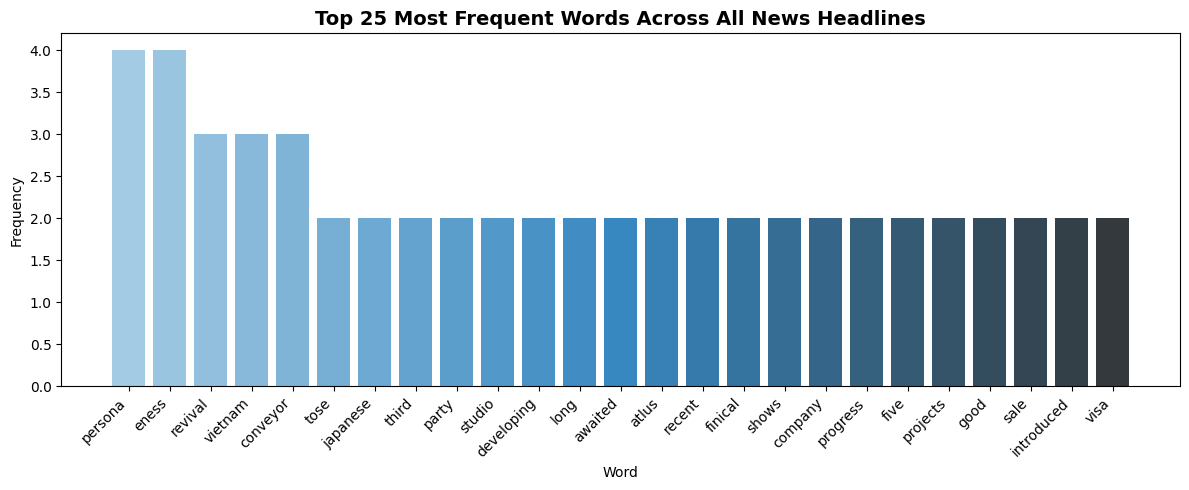

✅ Frequency chart displayed


In [28]:
plt.figure(figsize=(12, 5))
bars = plt.bar(words, counts, color=sns.color_palette("Blues_d", 25))
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.title("Top 25 Most Frequent Words Across All News Headlines", fontsize=14, fontweight='bold')
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()
print("✅ Frequency chart displayed")

In [35]:
print(all_tokens)
text_for_cloud = " ".join(all_tokens)
print(text_for_cloud)

['persona', 'revival', 'due', 'completed', 'end', 'august', 'release', 'early', 'nintendo', 'news', 'tose', 'japanese', 'third', 'party', 'studio', 'developing', 'long', 'awaited', 'persona', 'revival', 'atlus', 'recent', 'finical', 'shows', 'company', 'progress', 'five', 'projects', 'tose', 'japanese', 'third', 'party', 'studio', 'developing', 'long', 'awaited', 'persona', 'revival', 'atlus', 'recent', 'finical', 'shows', 'company', 'progress', 'five', 'projects', 'persona', 'asiana', 'airlines', 'seattle', 'chi', 'minh', 'city', 'vietnam', 'roundtrip', 'including', 'taxes', 'good', 'sale', 'vietnamvietnam', 'introduced', 'visa', 'system', 'take', 'advantage', 'cheapest', 'option', 'matrix', 'airfare', 'search', 'price', 'use', 'dates', 'priceline', 'good', 'sale', 'vietnam', 'vietnam', 'introduced', 'visa', 'system', 'take', 'advantage', 'cheapest', 'option', 'matrix', 'airfare', 'search', 'price', 'use', 'dates', 'priceline', 'repri', 'eness', 'creates', 'conveyor', 'belt', 'fantasy

In [37]:
wc = WordCloud(
   width=900, height=400,
   background_color='white',
   colormap='RdYlGn',
   max_words=150,
   collocations=False
).generate(text_for_cloud)

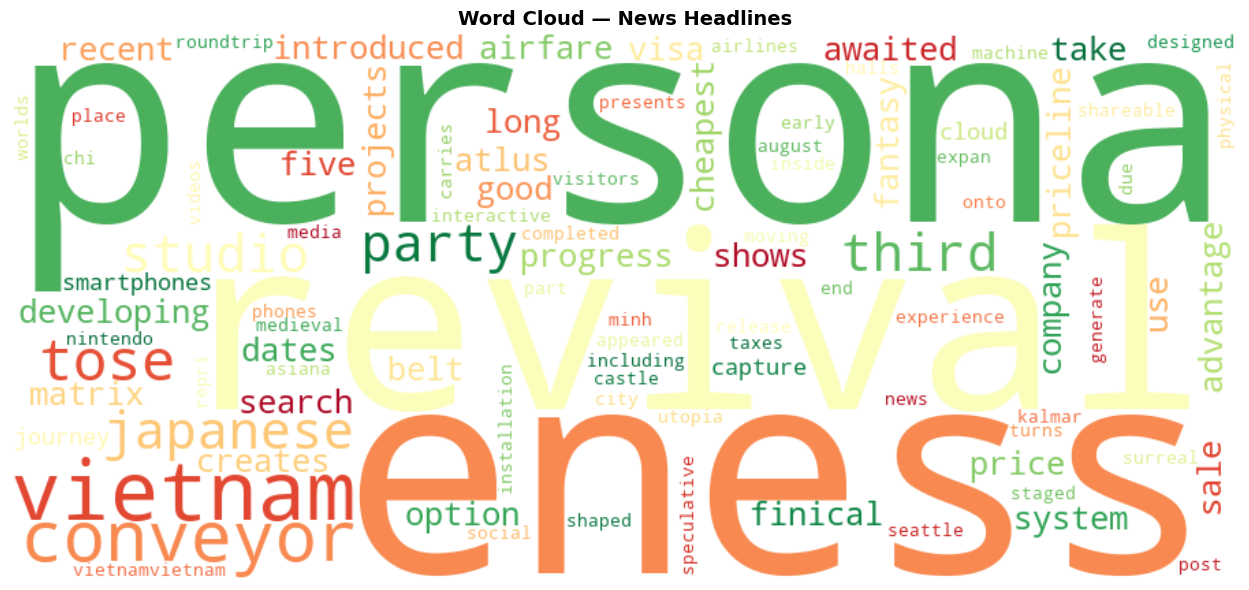

✅ Word cloud displayed


In [38]:
plt.figure(figsize=(14, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud — News Headlines", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ Word cloud displayed")

In [39]:
tagged = nltk.pos_tag(df["tokens"][0])
print(tagged)

[('persona', 'NN'), ('revival', 'NN'), ('due', 'JJ'), ('completed', 'VBN'), ('end', 'NN'), ('august', 'NN'), ('release', 'NN'), ('early', 'JJ'), ('nintendo', 'JJ'), ('news', 'NN'), ('tose', 'VB'), ('japanese', 'JJ'), ('third', 'JJ'), ('party', 'NN'), ('studio', 'NN'), ('developing', 'VBG'), ('long', 'RB'), ('awaited', 'VBN'), ('persona', 'NN'), ('revival', 'NN'), ('atlus', 'JJ'), ('recent', 'JJ'), ('finical', 'NN'), ('shows', 'NNS'), ('company', 'NN'), ('progress', 'RB'), ('five', 'CD'), ('projects', 'NNS'), ('tose', 'VBP'), ('japanese', 'JJ'), ('third', 'JJ'), ('party', 'NN'), ('studio', 'NN'), ('developing', 'VBG'), ('long', 'RB'), ('awaited', 'VBN'), ('persona', 'NN'), ('revival', 'NN'), ('atlus', 'JJ'), ('recent', 'JJ'), ('finical', 'NN'), ('shows', 'NNS'), ('company', 'NN'), ('progress', 'RB'), ('five', 'CD'), ('projects', 'NNS'), ('persona', 'VBP')]


In [40]:
# ──Part-of-Speech (POS) tagging  — identify noun-heavy vs action-heavy headlines ──
def pos_tag_summary(tokens: list) -> dict:
   """Return counts of nouns, verbs, adjectives in a token list."""
   tagged = nltk.pos_tag(tokens)
   pos_counts = {"NN": 0, "VB": 0, "JJ": 0}  # nouns, verbs, adjectives
   for _, tag in tagged:
       if tag.startswith("NN"): pos_counts["NN"] += 1
       elif tag.startswith("VB"): pos_counts["VB"] += 1
       elif tag.startswith("JJ"): pos_counts["JJ"] += 1
   return pos_counts

In [41]:
sample_df = df.head(50).copy()

In [42]:
sample_df["pos_tags"] = sample_df["tokens"].apply(pos_tag_summary)
sample_df["noun_count"] = sample_df["pos_tags"].apply(lambda x: x["NN"])
sample_df["verb_count"] = sample_df["pos_tags"].apply(lambda x: x["VB"])
sample_df["adj_count"]  = sample_df["pos_tags"].apply(lambda x: x["JJ"])
sample_df.head()

,title,description,source,url,published_at,category,full_text,clean_text,proper_nouns,tickers,tokens,token_count,pos_tags,noun_count,verb_count,adj_count
0,Persona 4 Revival due to be completed end of A...,Tose is the Japanese third party studio which ...,My Nintendo News,https://mynintendonews.com/2026/05/04/persona-...,2026-05-04T13:36:51Z,technology,Persona 4 Revival due to be completed end of A...,persona revival due to be completed end of aug...,[My Nintendo News Tose],[],"[persona, revival, due, completed, end, august...",47,"{'NN': 22, 'VB': 8, 'JJ': 11}",22,8,11
1,"Asiana Airlines: Seattle – Ho Chi Minh City, V...",A good sale to VietnamVietnam introduced a new...,Theflightdeal.com,https://www.theflightdeal.com/2026/05/04/asian...,2026-05-04T17:03:38Z,kw:economy,"Asiana Airlines: Seattle – Ho Chi Minh City, V...",asiana airlines seattle ho chi minh city vietn...,"[Asiana Airlines, Ho Chi Minh City, Matrix Air...",[],"[asiana, airlines, seattle, chi, minh, city, v...",46,"{'NN': 28, 'VB': 8, 'JJ': 7}",28,8,7
2,ENESS creates a conveyor-belt AI fantasy where...,visitors place their phones onto a moving conv...,Designboom,https://www.designboom.com/art/eness-conveyor-...,2026-05-04T17:00:08Z,kw:artificial intelligence,ENESS creates a conveyor-belt AI fantasy where...,eness creates a conveyor belt ai fantasy where...,"[Kalmar Castle, The Cloud Utopia Machine]","[ENESS, AI]","[eness, creates, conveyor, belt, fantasy, smar...",55,"{'NN': 29, 'VB': 12, 'JJ': 12}",29,12,12


In [43]:
print("POS distribution (sample of 50 headlines):")
print(f"  Avg nouns per headline:      {sample_df['noun_count'].mean():.1f}")
print(f"  Avg verbs per headline:      {sample_df['verb_count'].mean():.1f}")
print(f"  Avg adjectives per headline: {sample_df['adj_count'].mean():.1f}")

POS distribution (sample of 50 headlines):
  Avg nouns per headline:      26.3
  Avg verbs per headline:      9.3
  Avg adjectives per headline: 10.0
